# Objectif du notebook 

Date de création : 13/01/2026

L'objectif est de d'estimer le temps d'arrivée de chacun des signaux émis par la source. 

In [ ]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [ ]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color


# Chargement des données utiles 

In [ ]:
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Exemple avec un unique signal

## Chargement des informations relatives aux émissions 

In [ ]:
fpath = os.path.join(data_folder, "source_emissions_processed_dtypes.csv")
df_dtypes= pd.read_csv(fpath, index_col=0).to_dict()["dtype"]

fpath = os.path.join(data_folder, "source_emissions_processed.csv")
col_to_parse_date = [key for key in df_dtypes.keys() if "datetime" in df_dtypes[key]]
# Remove these columns from df_dtypes as they will be parsed as dates
for col in col_to_parse_date:
    df_dtypes.pop(col)
# Load dataframe with specified dtypes and parse dates
df = pd.read_csv(fpath, dtype=df_dtypes, parse_dates=col_to_parse_date)

In [ ]:
df.dtypes       # Here can verifiy that the dtypes are correctly assigned

## Sélection d'une partie des émissions

In [ ]:
# First select the emission with a required level
vc_carte = 2
df_sel= df[df["Vc carte (V)"] == vc_carte]
df_sel.reset_index(drop=True, inplace=True)

# Select the type of signal
signal_type = "chirp"       # "chirp" or "sinus"
df_sel = df_sel[df_sel["Signal"] == signal_type]
df_sel.reset_index(drop=True, inplace=True)

# Select the type of emission "fixed" or "trailed"
emission_type = "fixed"    # "fixed" or "trailed"
df_sel = df_sel[df_sel["Source"] == emission_type]
df_sel.reset_index(drop=True, inplace=True)

# Select a given day
day = datetime(2025, 10, 15)
df_sel = df_sel[df_sel["Emission datetime"].dt.date == day.date()]

### Remarque : calcul de la position de la source 
Le dataframe df contient la position de l'antenne GPS estimée à l'instant de l'émission. En pratique, la source n'est pas colocalisée avec l'antenne et il faut théoriquement prendre en compte ce bras de levier.

Au moins dans le cas des émissions en statique on peut considérer, au regard de l'incertitude sur le positionnement de l'antenne GPS à l'instant émission (incertitude GPS standard + interpolation linéaire entre deux points GPS), que la source est colocalisée avec l'antenne GPS. 

Dans le cas dynamique la longueur filée est importante $\approx$ 15/20 m. Dans ce cas, il peut être plus difficile de négliger le bras de levier entre l'antenne GPS et la source immergée. La longueur filée est connue ainsi que l'immersion de la source (capteur de pression sur la source), on peut ainsi calculer la distance (à la surface) de l'antenne GPS à la source (dans l'axe du navire). Néanmoins, afin de transformer ce bras de levier dans le repère du navire en un offset sur la position dans le repère ENU il est nécessaire de connaitre le cap du navire dans le repère ENU. 

Pour ce faire, on peut estimer le cap du navire à partir de l'estimation du vecteur vitesse du navire à l'instant d'émission : 

$$ V_{gps}^{(ENU)} = [V_e, V_n]^T$$

$$V_e = \frac{E_{gps}(t_{n+1}) - E_{gps}(t_n)}{\Delta t}$$
et 
$$V_n = \frac{N_{gps}(t_{n+1}) - N_{gps}(t_n)}{\Delta t}$$

où $t_n$ et $t_{n+1}$ sont les instants précèdent et successif à l'instant d'émission dans la série temporelle des positions GPS. 

Le cap du navire dans le repère ENU est alors donné par : 

$$\alpha = \arctan{\frac{V_e}{V_n}}$$

La position dans le repère du navire est (hypothèse source dans l'axe du navire):

$$X_s^{(Navire)} = [0, -bdl]^T$$

où $bdl$ est la distance, selon l'axe $y_{navire}$, de l'origine du repère du navire (position de l'antenne GPS) au projeté orthogonal de la position de la source sur la surface. 

Finalement :

$$X_s^{(ENU)} = X_{GPS}^{(ENU)} + R_{\text{Nav to ENU}} X_s^{(Navire)}$$

avec 
$$ R_{\text{Nav to ENU}} = \begin{bmatrix} \cos{\alpha} & \sin{\alpha} \\ -\sin{\alpha} & \cos{\alpha} \end{bmatrix}$$

Proche des OBS la correction pourrait avoir un impacte significatif. 

In [ ]:
# Function to compute the real position of the source considering the offset 
# e_gps_poulie = 



In [ ]:
def get_wav_file_for_emission(emission_datetime, start_datetime_arr, wav_start_times):
    # Compute time differences between emission and wav start times
    dt = emission_datetime - start_datetime_arr
    # Keep only positive time differences (we are only looking for wav files that start before the emission)
    dt_is_positive = dt >= pd.Timedelta(0)
    # Find closest
    wav_start_datetime = start_datetime_arr[dt_is_positive][-1]
    # Get corresponding wav file path
    wav_fpath = wav_start_times[wav_start_datetime]
    return wav_fpath, wav_start_datetime

In [ ]:
def get_tr_apriori(emission_pos, wav_start_datetime, emission_datetime, obs_id):
    # Extract emission position
    e_emission, n_emission, u_emission = emission_pos

    # Get receiver apriori position
    e_obs = ds_gps.attrs[f"obs{obs_id}_e_apriori"]
    n_obs = ds_gps.attrs[f"obs{obs_id}_n_apriori"]
    u_obs = ds_gps.attrs[f"obs{obs_id}_u_apriori"]

    # Derive apriori propagation distance
    prop_range = np.sqrt(
        (e_emission - e_obs) ** 2
        + (n_emission - n_obs) ** 2
        + (u_emission - u_obs) ** 2
    )

    # Derive apriori propagation time
    c0 = 1500
    prop_time = prop_range / c0

    # Deduce apriori reception time
    reception_datetime = emission_datetime + pd.Timedelta(prop_time, "s")

    # Derive reception time from wav start
    tr = reception_datetime - wav_start_datetime
    # Convert to seconds
    tr = tr.total_seconds()

    return reception_datetime, tr, prop_time

In [ ]:
import scipy.signal as sp

def apply_match_filter(signal, fs, f0, f1, T):
    """
    Apply match filtering to a chirp signal.
    
    Parameters:
    signal : ndarray
        The received signal to be processed.
    fs : float
        Sampling frequency in Hz.
    f0 : float
        Start frequency of the chirp in Hz.
    f1 : float
        End frequency of the chirp in Hz.
    T : float
        Duration of the chirp in seconds.
        
    Returns:
    compressed_signal : ndarray
        The pulse-compressed signal.
    """
    # Generate the reference chirp signal
    t = np.arange(0, T, 1/fs)
    reference_chirp = sp.chirp(t, f0=f0, f1=f1, t1=T, method="linear")

    # Perform matched filtering (cross-correlation)
    sig_mf = np.correlate(signal, reference_chirp, mode='same')
    lags = (
        sp.correlation_lags(t.size, t.size, mode="same") * 1 / fs
    )
    return lags, sig_mf

In [ ]:
# def

In [ ]:
def plot_arrivals_detection(
    t_win,
    signal_win,
    sig_mf,
    t_arrivals,
    peaks_idx,
    peak_times,
    first_emission_reception_datetime,
    last_emission_reception_datetime,
    sequence_info,
    signal_params,
    t_hydro_source_offset=31,
    save=False,
    fs=2000,
    nperseg=64,
    noverlap=32,
    first_emission_in_sequence_datetime=None,
    last_emission_in_sequence_datetime=None,
    verbose=False,
    plot_zoom=False,
):

    if verbose:
        print("Plotting arrivals...")

    # Unwrap sequence information
    seq_id = sequence_info.get("seq_id", None)
    obs_id = sequence_info.get("obs_id", None)
    vc_carte = sequence_info.get("vc_carte", None)
    signal_type = sequence_info.get("signal_type", None)
    emission_type = sequence_info.get("emission_type", None)

    # Normalize signal for better visualization
    signal_win = signal_win / np.max(np.abs(signal_win))

    # Compute spectrogram for visualization
    ff, tt, Sxx = sp.stft(
        signal_win,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",
    )
    tt_datetime = pd.date_range(
        t_win[0], t_win[0] + pd.Timedelta(tt[-1], "s"), freq=f"{tt[1]-tt[0]}s", inclusive="both"
    )

    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    # Plot raw signal
    axs[0].plot(t_win, signal_win, color="k")
    axs[0].set_ylim([-1, 1])
    # Plot matched filtered signal
    axs[1].plot(t_win, sig_mf, color="k")
    axs[1].set_ylim([-1, 1])

    # Add detected peaks
    if len(peaks_idx) > 0:
        axs[1].scatter(
            peak_times,
            sig_mf[peaks_idx],
            marker="o",
            color="r",
            label=r"$t_{\text{peak}}$",
            s=5,
            zorder=10,
        )

    axs[0].set_ylabel("s")
    axs[1].set_ylabel(r"$s_{mf}$")

    im = axs[2].pcolormesh(tt_datetime, ff, 10 * np.log10(np.abs(Sxx)), cmap="jet")
    # fig.colorbar(im, cax=axs[2], label=r"Pa$^2$ / Hz in dB")
    axs[2].set_ylabel("Fréquence [Hz]")

    # Add arrivals
    if len(t_arrivals) > 0:
        # Plot arrows for arrivals
        for iarr, t_arrival in enumerate(t_arrivals):
            axs[0].annotate(
                f"{iarr}",
                xy=(t_arrival, 0.5),
                xytext=(t_arrival, 0.9),
                arrowprops=dict(arrowstyle="->", color="red"),
                horizontalalignment="center",
                verticalalignment="center",
            )
            axs[2].annotate(
                f"{iarr}",
                xy=(t_arrival, np.max(ff) * 0.75),
                xytext=(t_arrival, np.max(ff) * 0.95),
                arrowprops=dict(arrowstyle="->", color="black"),
                horizontalalignment="center",
                verticalalignment="center",
            )

    for i in range(len(axs)):
        axs[i].axvline(
            first_emission_reception_datetime,
            color="g",
            linestyle="--",
            label=r"$T_{\text{reception}}(\text{first})$",
        )
        axs[i].axvline(
            last_emission_reception_datetime,
            color="b",
            linestyle="--",
            label=r"$T_{\text{reception}}(\text{last})$",
        )
        if first_emission_in_sequence_datetime is not None:
            axs[i].axvline(
                first_emission_in_sequence_datetime,
                color="red",
                linestyle="--",
                label=r"$T_{\text{emission}}(\text{first})$",
            )
        if last_emission_in_sequence_datetime is not None:
            axs[i].axvline(last_emission_in_sequence_datetime, color="red", linestyle="--", label=r"$T_{\text{emission}}(\text{last})$")

    for i in range(len(axs)):
        axs[i].axvline(
            first_emission_reception_datetime
            + pd.Timedelta(t_hydro_source_offset, "s"),
            color="g",
            linestyle="-",
            label=r"$T_{\text{reception}}(\text{first}) + \tau_{H_{\text{source}}}$",
        )

        axs[i].axvline(
            last_emission_reception_datetime + pd.Timedelta(t_hydro_source_offset, "s"),
            color="b",
            linestyle="-",
            label=r"$T_{\text{reception}}(\text{last}) + \tau_{H_{\text{source}}}$",
        )
        if first_emission_in_sequence_datetime is not None:
            axs[i].axvline(
                first_emission_in_sequence_datetime
                + pd.Timedelta(t_hydro_source_offset, "s"),
                color="red",
                linestyle="-",
                label=r"$T_{\text{emission}}(\text{first}) + \tau_{H_{\text{source}}}$",
            )
        if last_emission_in_sequence_datetime is not None:
            axs[i].axvline(
                last_emission_in_sequence_datetime + pd.Timedelta(t_hydro_source_offset, "s"),
                color="red",
                linestyle="-",
                label=r"$T_{\text{emission}}(\text{last}) + \tau_{H_{\text{source}}}$",
            )

    for i in range(len(axs)):
        axs[i].legend(ncols=2, loc="lower left")

    fig.supxlabel("Temps UTC")
    # fig.supylabel("Signal")
    fig.suptitle(
        f"Sequence ID {seq_id} - OBS{obs_id} \n Vc carte = {vc_carte} V - Signal: {signal_type} - Source: {emission_type}"
    )

    if save:
        img_fname = f"arrival_detection_seqID{seq_id}_OBS{obs_id}.png"
        img_fpath = os.path.join(img_folder, "reception", "arrivals_detection", img_fname)
        fig.savefig(img_fpath, dpi=300)

    # Plot a zoom on the first emission reception
    if len(peaks_idx) > 0 and plot_zoom:

        Bw = signal_params["f1"] - signal_params["f0"]
        Tmf = 1 / Bw
        # Tmf = signal_params["chirp_T"]
        alpha_tmf = 30
        zoom_win_duration = pd.Timedelta(0.05, "s")
        fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
        axs[0].plot(t_win, signal_win)
        axs[0].set_ylabel("s")
        axs[1].plot(t_win, sig_mf)
        axs[1].vlines(
            peak_times - pd.Timedelta(alpha_tmf * Tmf / 2, "s"),
            ymin=-1,
            ymax=1,
            color="r",
            linestyle="--",
            label=fr"$t_{{\text{{peak}}}} - {alpha_tmf} \times \frac{{T_{{mf}}}}{{2}}$",
        )
        axs[1].vlines(
            peak_times + pd.Timedelta(alpha_tmf * Tmf / 2, "s"),
            ymin=-1,
            ymax=1,
            color="r",
            linestyle="--",
            label=rf"$t_{{\text{{peak}}}} + {alpha_tmf} \times \frac{{T_{{mf}}}}{{2}}$",
        )

        # Add detected peaks
        axs[0].scatter(
            peak_times,
            signal_win[peaks_idx],
            marker="o",
            color="r",
            label=r"$t_r$",
            s=5,
            zorder=10,
        )
        axs[1].scatter(
            peak_times,
            sig_mf[peaks_idx],
            marker="o",
            color="r",
            label=r"$t_{\text{peak}}$",
            s=5,
            zorder=10,
        )
        axs[1].set_ylabel(r"$s_{mf}$")

        # # Plot signal phase
        # sig_mf_fft = np.fft.fft(sig_mf)
        # sig_mf_phase = np.angle(sig_mf_fft)
        # axs[2].plot(t_win, sig_mf_phase)
        # axs[2].set_ylabel(r"$\phi$ [rad]")

        im = axs[2].pcolormesh(tt_datetime, ff, 10 * np.log10(np.abs(Sxx)), cmap="jet")
        axs[2].set_ylabel("Fréquence [Hz]")
        for i in range(len(axs)):
            axs[i].set_xlim(
                peak_times[0] - 1 / 2 * zoom_win_duration,
                peak_times[0] + 1 / 2 * zoom_win_duration,
            )
        axs[0].legend(ncols=2, loc="upper right")
        axs[1].legend(ncols=2, loc="upper right")

        fig.supxlabel("Temps UTC")
        fig.suptitle(
            f"Sequence ID {seq_id} - OBS{obs_id} \n Vc carte = {vc_carte} V - Signal: {signal_type} - Source: {emission_type}"
        )

        if save:
            img_fname = (
                f"arrival_detection_seqID{seq_id}_OBS{obs_id}_first_arrival_zoom.png"
            )
            img_fpath = os.path.join(img_folder, "reception", "arrivals_detection", img_fname)
            fig.savefig(img_fpath, dpi=300)

In [ ]:
def get_arrivals(signal_win, t_win, df_sequence, fs, verbose=False):

    if verbose:
        print("Applying matched filtering to detect arrivals...")

    # Extract signal parameters
    f0 = df_sequence["Frequency min (Hz)"].iloc[0]
    f1 = df_sequence["Frequency max (Hz)"].iloc[0]
    chirp_T = df_sequence["Duration (s)"].iloc[0]
    T_repeat = df_sequence["Trepeat (s)"].iloc[0]
    signal_params = {
        "f0": f0,
        "f1": f1,
        "chirp_T": chirp_T,
        "T_repeat": T_repeat,
    }

    # Apply matched filtering
    lags, sig_mf = apply_match_filter(signal_win, fs, f0, f1, chirp_T)
    # Normalize matched filtered signal
    sig_mf = sig_mf / np.max(np.abs(sig_mf))

    # Find peaks in matched filtered signal
    dist = 0.9 * T_repeat * fs
    peaks_idx, properties = sp.find_peaks(
        sig_mf, height=np.std(sig_mf) * 5, distance=dist
    )
    peak_times = t_win[peaks_idx]

    # Correct arrivals for chirp duration
    t_arrivals = peak_times - pd.Timedelta(1/2 * chirp_T, "s") 

    return peaks_idx, peak_times, t_arrivals, sig_mf, signal_params

In [ ]:
pfig = PubFigure(
    label_fontsize=18, legend_fontsize=10, ticks_fontsize=16, title_fontsize=20
)

In [ ]:
def get_available_wav_files(obs_id):
    # Get the list of wav file available for selected obs_id
    obs_wav_dir = os.path.join(root_groix_wav, f"OBS{obs_id+3}", "vitesse")
    # List all wav files in the directory
    wav_files = os.listdir(obs_wav_dir)
    # Extract start times from filenames
    wav_start_times = {}
    for wav_file in wav_files:
        if wav_file.endswith(".wav"):
            date = wav_file.split("_")[2]
            time = wav_file.split("_")[3].split("-vel")[0]
            timestamp_str = f"{date}_{time}"
            date_fmt = "%Y-%m-%d_%H-%M-%S"
            file_start_datetime = datetime.strptime(timestamp_str, date_fmt)
            wav_start_times[file_start_datetime] = os.path.join(obs_wav_dir, wav_file)

    start_datetime_arr = np.array(list(wav_start_times.keys()))

    return wav_start_times, start_datetime_arr

In [ ]:
def detected_arrivals_psnr(sig_mf, peaks_idx, signal_params, fs, plot=False):
    # Define a window around each arrival
    bandwidth = signal_params["f1"] - signal_params["f0"]
    Tmf = 1 / bandwidth
    alpha_tmf = 150
    # Proceed sequentially for each detected arrival
    mf_time = np.arange(len(sig_mf)) / fs
    psnr_arrivals = []
    for iarr, peak_idx in enumerate(peaks_idx):

        # Select signal portion around the arrival
        tmin = mf_time[peak_idx] - signal_params["T_repeat"] / 10
        tmin = max(tmin, 0)
        nmin = int(tmin * fs)
        tmax = mf_time[peak_idx] + signal_params["T_repeat"] / 10
        tmax = min(tmax, mf_time[-1])
        nmax = int(tmax * fs)
        sig_mf_portion = sig_mf[nmin:nmax]

        # Define masks for signal and noise windows
        mask_signal = np.zeros_like(sig_mf, dtype=bool)

        # Set mask to True in the signal window
        tmin_sig = mf_time[peak_idx] - alpha_tmf * Tmf / 2 
        tmin_sig = max(tmin_sig, 0)
        nmin_sig = int(tmin_sig * fs)
        tmax_sig = mf_time[peak_idx] + alpha_tmf * Tmf / 2 
        tmax_sig = min(tmax_sig, mf_time[-1])
        nmax_sig = int(tmax_sig * fs)

        mask_signal[nmin_sig:nmax_sig] = True
        mask_signal_win = mask_signal[nmin:nmax]

        noise_win_portion = sig_mf_portion[~mask_signal_win]
        noise_rms = np.sqrt(np.mean(noise_win_portion**2))
        sig_peak = sig_mf[peak_idx]
        peak_signal_to_noise_rms = sig_peak / noise_rms 
        psnr_arrivals.append(peak_signal_to_noise_rms)

        if plot:
            plt.figure()
            plt.plot(mf_time[nmin:nmax], sig_mf_portion, label="Matched Filtered Signal Portion")
            plt.plot(
                mf_time[nmin:nmax][mask_signal_win],
                sig_mf_portion[mask_signal_win],
                color="orange",
                label="Signal Window",
            )
            plt.axvline(mf_time[peak_idx], color="red", linestyle="--", label="Arrival Time")
            plt.axvline(tmin_sig, color="green", linestyle="--", label="-Tmf")
            plt.axvline(tmax_sig, color="green", linestyle="--", label="+Tmf")
            plt.axhline(noise_rms, color="k", linestyle="--", label="noise rms")
            plt.legend()

            plt.show()

    return np.array(psnr_arrivals)

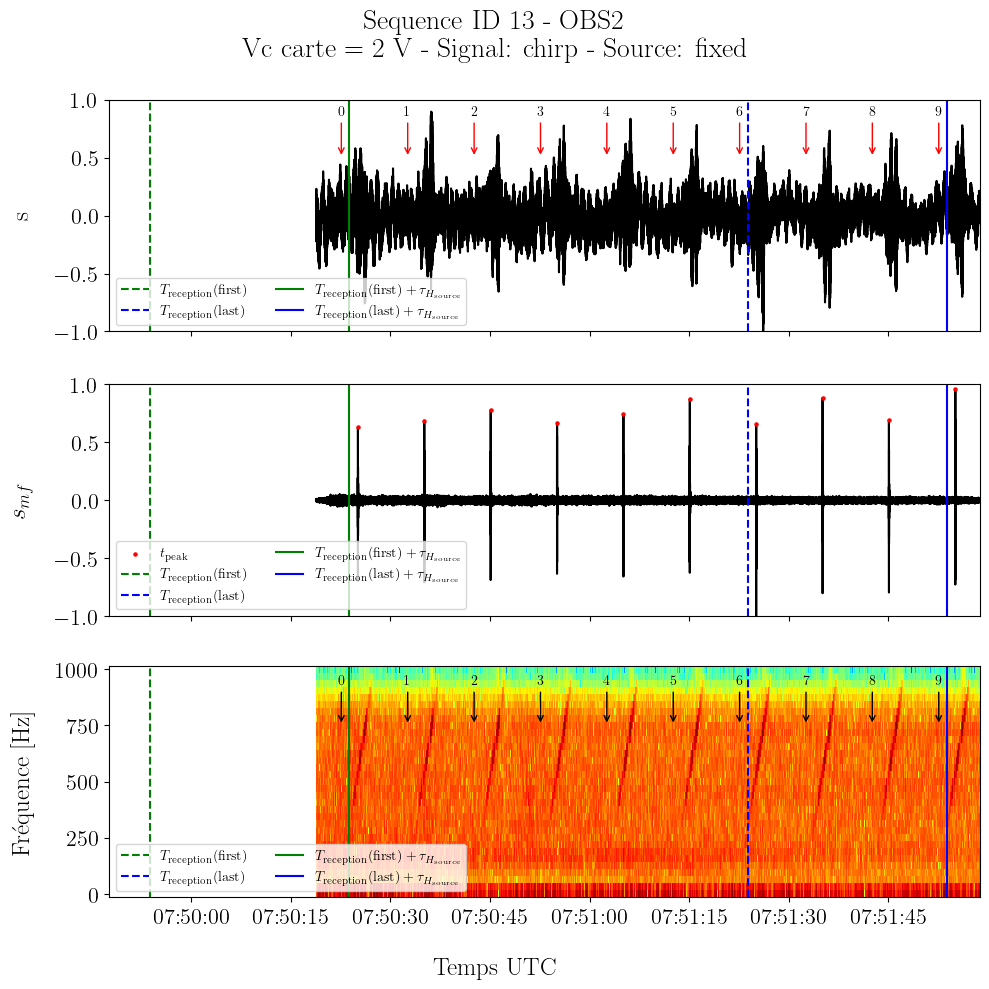

In [20]:
obs_id = 1  # Correspondance OBS 1 = OBS 4, OBS 2 = OBS 5, OBS 3 = OBS 6

verbose = False
savefig = True
plot = True
plot_zoom = False

# Convention Gen_Axes_D_V4 (Cf ELOBSBin2Wav.py)
channels_order = {
    "Z": 0,
    "X": 1,
    "Y": 2,
    "H": 3,
}
used_channel = "H"


# TODO : check to remove this or to moove it earlier
t_hydro_source_offset = 30    # seconds

# Window parameters
pre_reception_time = 5.0    # seconds before reception to include in the window
post_reception_time = 5.0   # seconds after reception to include in the window

# Correct window for hydrophone to source offset
pre_reception_time -= t_hydro_source_offset
post_reception_time += t_hydro_source_offset

origin_keys = df_sel.columns.to_list()
processed_keys = origin_keys
processed_data = {key: [] for key in processed_keys}

# Main loop over emission sequence
sel_sequence_id = df_sel["Sequence_id"].unique()
# sel_sequence_id = sel_sequence_id[:2]   # Reduce the number of sequence to process for debugging / test
for seq_id in sel_sequence_id:
    df_sequence = df_sel.loc[df_sel["Sequence_id"] == seq_id]

    new_data = {}
    # Lood over receivers
    for obs_id in [1, 2, 3]:

        # Get available wav files for the selected OBS
        wav_start_times, start_datetime_arr = get_available_wav_files(obs_id)

        ### Load signal of interest ###
        # Get all theoretical arrival time
        emissions_datetime = []
        th_arrivals_datetime = []
        th_propagation_delay = []
        th_arrivals_seconds_from_start = []
        for emission_id in range(df_sequence.shape[0]):
            emission_i = df_sequence.iloc[emission_id]
            emission_i_datetime = emission_i["Emission datetime"].to_pydatetime(warn=False)
            emissions_datetime.append(emission_i_datetime)

            if emission_id == 0:        # First emission in sequence 
                # Find the corresponding wav file (for now we assume that the sequence fits in a single wav file)
                wav_fpath, wav_start_datetime = get_wav_file_for_emission(
                    emission_datetime=emission_i_datetime,
                    start_datetime_arr=start_datetime_arr,
                    wav_start_times=wav_start_times,
                )
                print(f"Corresponding wav file (OBS{obs_id}): {wav_fpath}")

            # Emission position
            emission_i_pos = [
                emission_i["Emission interpolated N GPS"],
                emission_i["Emission interpolated U GPS"],
                emission_i["Emission interpolated E GPS"],
            ]
            # Theoretical time of arrival
            emission_i_reception_datetime, tr_i, prop_time_i = get_tr_apriori(
                emission_i_pos,
                wav_start_datetime,
                emission_i_datetime,
                obs_id,
            )
            th_propagation_delay.append(prop_time_i)
            th_arrivals_datetime.append(emission_i_reception_datetime)
            th_arrivals_seconds_from_start.append(tr_i)

        # Convert to numpy arrays
        th_propagation_delay = np.array(th_propagation_delay)
        th_arrivals_datetime = np.array(th_arrivals_datetime)
        th_arrivals_seconds_from_start = np.array(th_arrivals_seconds_from_start)

        # First emission in the sequence
        first_emission_in_sequence_datetime = emissions_datetime[0] 
        first_emission_reception_datetime = th_arrivals_datetime[0]
        tr_first = th_arrivals_seconds_from_start[0]
        # Last emission in sequence
        last_emission_in_sequence_datetime = emissions_datetime[-1]
        last_emission_reception_datetime = th_arrivals_datetime[-1]
        tr_last = th_arrivals_seconds_from_start[-1]
        print(
            f"Processing sequence {seq_id} from {first_emission_in_sequence_datetime} to {last_emission_in_sequence_datetime}"
        )

        # Load the wav file
        print("Loading wav file...")
        # Read the wav file
        signal, fs = sf.read(wav_fpath)
        # Select the channel
        signal = signal[:, channels_order[used_channel]]
        # Remove mean
        signal = signal - np.mean(signal)

        # Compute source position considering the offset for the current emission   (Source, Longueur filée)
        # TODO : implement position correction if needed

        # Select the time window of interest for current sequence (all emissions in the sequence + pre/post times)
        t_start_win = tr_first - pre_reception_time
        t_end_win = tr_last + post_reception_time

        # Convert in samples
        n_samp_start_win = int(t_start_win * fs)
        n_samp_end_win = int(t_end_win * fs)
        # Slice signal
        signal_win = signal[n_samp_start_win:n_samp_end_win]
        wav_end_datetime = wav_start_datetime + pd.Timedelta(signal.shape[0] * 1/fs, "s")
        t_dt = pd.date_range(wav_start_datetime, wav_end_datetime, freq=f"{1/fs}s", inclusive="left")
        t_win = t_dt[n_samp_start_win:n_samp_end_win]
        print(f"Original signal from {wav_start_datetime} to {wav_end_datetime}")
        print(f"Selected window from {t_win[0]} to {t_win[-1]}")

        ### Get arrivals ###
        peaks_idx, peak_times, t_arrivals, sig_mf, signal_params = get_arrivals(
            signal_win,
            t_win,
            df_sequence,
            fs,
            verbose=verbose,
        )

        ### Plot arrivals ###
        if plot:
            sequence_info = {
                "seq_id": seq_id,
                "obs_id": obs_id,
                "vc_carte": vc_carte,
                "signal_type": signal_type,
                "emission_type": emission_type,
            }
            nperseg=64
            noverlap=int(nperseg*0.5)

            plot_arrivals_detection(
                t_win=t_win,
                signal_win=signal_win,
                sig_mf=sig_mf,
                t_arrivals=t_arrivals,
                peaks_idx=peaks_idx,
                peak_times=peak_times,
                first_emission_reception_datetime=first_emission_reception_datetime,
                last_emission_reception_datetime=last_emission_reception_datetime,
                sequence_info=sequence_info,
                signal_params=signal_params,
                t_hydro_source_offset=t_hydro_source_offset,
                save=savefig,
                fs=fs,
                nperseg=nperseg,
                noverlap=noverlap,
                first_emission_in_sequence_datetime=None,
                last_emission_in_sequence_datetime=None,
                verbose=verbose,
                plot_zoom=plot_zoom,
            )

            plt.close("all")

        # Convert t_arrivals into datetime.datetime
        t_arrivals_dt = np.array([t_arr.to_pydatetime(warn=False) for t_arr in t_arrivals])

        valid_detection = np.zeros_like(emissions_datetime, dtype=bool)
        # Pad in case not all peaks are detected
        t_arrivals_full = np.empty_like(emissions_datetime)
        t_arrivals_full[:] = pd.NaT
        for t_arr_dt in t_arrivals_dt:
            # Associate arrivals to closest theoretical arrival
            closest_th_arr_idx = np.argmin(np.abs(th_arrivals_datetime - t_arr_dt))
            # Replace in padded array
            t_arrivals_full[closest_th_arr_idx] = t_arr_dt
            # Set valid_detection flag to true
            valid_detection[closest_th_arr_idx] = True

        t_arrivals_dt = t_arrivals_full
        # Derive propagation time
        meas_propagation_delay = t_arrivals_dt - np.array(emissions_datetime)
        meas_propagation_delay = np.array([t.total_seconds() for t in meas_propagation_delay])

        ### Compute quality metrics for the detected arrivals ###
        ## Derive snr on matched filtered signal ##
        psnr_arrivals = detected_arrivals_psnr(sig_mf, peaks_idx, signal_params, fs, plot=False)
        # print(psnr_arrivals)

        # Add new data for current obs
        new_data[f"Arrival datetime OBS{obs_id}"] = list(t_arrivals.values)
        new_data[f"Theoretical propagation time OBS{obs_id}"] = list(th_propagation_delay)
        new_data[f"Measured propagation time OBS{obs_id}"] = list(meas_propagation_delay)
        new_data[f"PSNR OBS{obs_id}"] = list(psnr_arrivals)
        new_data[f"Valid detection {obs_id}"] = list(valid_detection)

    # Copy data for processed emissions
    for key in origin_keys:
        processed_data[key].extend(df_sequence[key].values)
    for key in new_data:
        if key in processed_data.keys():
            processed_data[key].extend(new_data[key])
        else:
            processed_data[key] = new_data[key]

    # processed_data[""]

# for key in processed_data.keys():
#     print(len(processed_data[key]))
# Convert to dataframe
df_processed = pd.DataFrame(processed_data)

In [ ]:
df_processed

In [ ]:
# # Loop over selected emissions
# idx = df_sel.index.tolist()[:5]   # Just take first 5 for testing

# for idx in idx: 
#     row = df_sel.loc[idx]
#     # print(row)

#     # Compute source position considering the offset for the current emission   (Source, Longueur filée)

#     # Find the corresponding wav file
#     emission_datetime = row["Emission datetime"].to_pydatetime()
#     wav_fpath, wav_start_datetime = get_wav_file_for_emission(emission_datetime)
#     # print(f"Emission datetime : {emission_datetime}")
#     # print(f"Corresponding wav file: {wav_fpath}")

#     # Load the wav file
#     print("Loading wav file...")
#     # sf_info = sf.info(wav_fpath)
#     # Read the wav file
#     signal, fs = sf.read(wav_fpath)
#     # Select the channel
#     signal = signal[:, channels_order[used_channel]]
#     # Select the time window corresponding to the emission
#     emission_pos = [
#         row["Emission interpolated E GPS"],
#         row["Emission interpolated N GPS"],
#         row["Emission interpolated U GPS"],
#     ]
#     # Tr : time in seconds from recording start corresponding to expected reception
#     reception_datetime, tr = get_tr_apriori(
#         emission_pos, wav_start_datetime, emission_datetime, obs_id
#     )
#     t_start_win = tr - pre_reception_time
#     t_end_win = tr + post_reception_time
#     # Convert in samples
#     n_samp_start_win = int(t_start_win * fs)
#     n_samp_end_win = int(t_end_win * fs)
#     # Slice signal
#     signal_win = signal[n_samp_start_win:n_samp_end_win]
#     wav_end_datetime = wav_start_datetime + pd.Timedelta(signal.shape[0] * 1/fs,"s")
#     t_dt = pd.date_range(wav_start_datetime, wav_end_datetime, freq=f"{1/fs}s", inclusive="left")
#     t_win = t_dt[n_samp_start_win:n_samp_end_win]

    Apply match filtering






#     print("Applying match filtering...")
#     # Extract signal parameters
#     f0 = row["Frequency min (Hz)"]
#     f1 = row["Frequency max (Hz)"]
#     chirp_T = row["Duration (s)"]
#     lags, sig_mf = apply_match_filter(signal_win, fs, f0, f1, chirp_T)

#     # Compute spectrogram for visualization
#     nperseg = 64
#     noverlap = int(nperseg * 0.5)
#     ff, tt, Sxx = sp.stft(
#         signal_win,
#         fs=fs,
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",
#     )
#     tt_datetime = pd.date_range(
#         t_win[0], t_win[0] + pd.Timedelta(tt[-1], "s"), freq=f"{tt[1]-tt[0]}s", inclusive="both"
#     )

#     print("Plotting results...")
#     fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
#     # Plot raw signal
#     axs[0].plot(t_win, signal_win)
#     # axs[0].set_xlabel("Temps UTC")
#     axs[0].set_ylabel("s")

#     # Plot matched filtered signal
#     axs[1].plot(t_win, sig_mf)
#     # axs[1].set_xlabel("Temps UTC")
#     axs[1].set_ylabel(r"$s_{mf}$")

#     im = axs[2].pcolormesh(tt_datetime, ff, 10 * np.log10(np.abs(Sxx)), cmap="jet")
#     # fig.colorbar(im, cax=axs[2], label=r"Pa$^2$ / Hz in dB")
#     axs[2].set_ylabel("Frequency [Hz]")
#     # axs[2].set_xlabel("Temps [s]")


#     fig.supxlabel("Temps UTC")
#     # fig.supylabel("Signal")
#     plt.show()
#     # signal =